In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
df = pd.read_csv("/home/admin-groep11/CVMatching-1/data/processed/labeled_jobdescriptions2_cleaned.csv")

In [ ]:
df = df.sample(frac=0.1, random_state=42)

df.to_csv("/home/admin-groep11/CVMatching-1/data/raw/dataset_klein.csv", index=False)


In [4]:
# Zet teksten naar string
df["resume_text"] = df["resume_text"].astype(str)
df["job_text"] = df["job_text"].astype(str)

In [5]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

# Fit alleen op (resumes + jobs)
corpus = df["resume_text"].tolist() + df["job_text"].tolist()
vectorizer.fit(corpus)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [6]:
resume_tfidf = vectorizer.transform(df["resume_text"])
job_tfidf = vectorizer.transform(df["job_text"])

In [7]:
similarities = []
for i in range(len(df)):
    sim = cosine_similarity(resume_tfidf[i], job_tfidf[i])[0][0]
    similarities.append(sim)

In [8]:

df["similarity_tfidf"] = similarities

print(df[["resume_id", "job_id", "similarity_tfidf", "label"]].head())

   resume_id  job_id  similarity_tfidf  label
0   14508237  349622          0.091238      0
1   39650734  348668          0.052990      0
2   70541112  321554          0.063991      1
3   11676151  350187          0.032550      0
4   32081266  347824          0.102678      1


Kolommen in dataset: ['job_id', 'resume_id', 'job_text', 'resume_text', 'label']

 TF-IDF matrix aangemaakt.
Vorm van matrix: (692, 5000)

 Top 20 woorden volgens TF-IDF:
water (0.0448)
health (0.0387)
construction (0.0366)
city (0.0361)
new (0.0329)
design (0.0310)
project (0.0308)
wastewater (0.0306)
program (0.0277)
management (0.0270)
work (0.0269)
york (0.0261)
projects (0.0255)
engineering (0.0250)
data (0.0248)
bureau (0.0246)
services (0.0244)
dep (0.0242)
staff (0.0241)
support (0.0229)

🧐 Aantal lege documenten: 1

Cosine similarity (eerste 10 documenten):
[[1.   0.05 0.07 0.02 0.06 0.04 0.03 0.06 0.05 0.04]
 [0.05 1.   0.21 0.03 0.02 0.04 0.04 0.02 0.31 0.27]
 [0.07 0.21 1.   0.03 0.07 0.04 0.07 0.06 0.29 0.39]
 [0.02 0.03 0.03 1.   0.03 0.07 0.12 0.03 0.03 0.05]
 [0.06 0.02 0.07 0.03 1.   0.05 0.02 0.26 0.15 0.2 ]
 [0.04 0.04 0.04 0.07 0.05 1.   0.04 0.08 0.02 0.04]
 [0.03 0.04 0.07 0.12 0.02 0.04 1.   0.02 0.02 0.07]
 [0.06 0.02 0.06 0.03 0.26 0.08 0.02 1.   0.04 0.12]
 [0

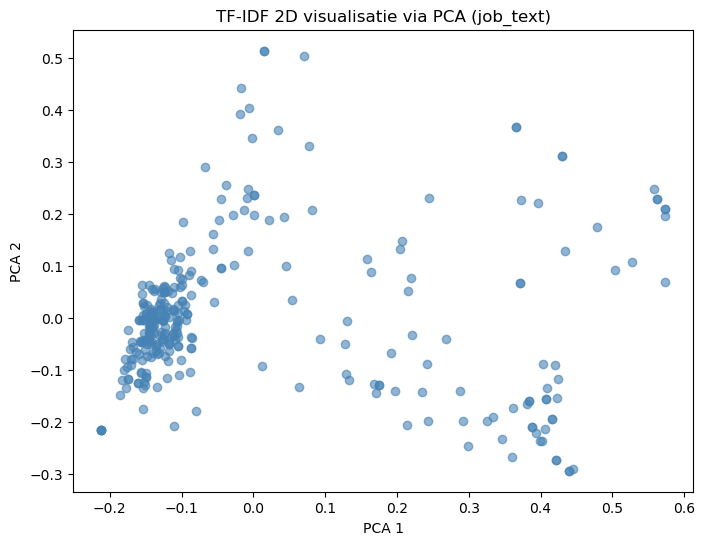

In [9]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("/home/admin-groep11/CVMatching-1/data/processed/labeled_jobdescriptions2_cleaned.csv")

print("Kolommen in dataset:", df.columns.tolist())

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["job_text"])

print("\n TF-IDF matrix aangemaakt.")
print("Vorm van matrix:", X.shape)

feature_names = vectorizer.get_feature_names_out()
mean_scores = X.mean(axis=0).A1
top_indices = np.argsort(mean_scores)[::-1][:20]

print("\n Top 20 woorden volgens TF-IDF:")
for idx in top_indices:
    print(f"{feature_names[idx]} ({mean_scores[idx]:.4f})")

empty_docs = (X.sum(axis=1) == 0).sum()
print(f"\n🧐 Aantal lege documenten: {empty_docs}")

sim_matrix = cosine_similarity(X[:10])
print("\nCosine similarity (eerste 10 documenten):")
print(np.round(sim_matrix, 2))

X_dense = X.toarray()
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X_dense[:300])  

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], alpha=0.6, color="steelblue")
plt.title("TF-IDF 2D visualisatie via PCA (job_text)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()
